# AB Testing

Agenda:
1. Randomized controlled experiments
2. AB testing
3. Statistics intuition - p-values, confidence intervals, power analysis
4. AB test workflow and analysing a real experiment
5. Caveats


In [1]:
import warnings
warnings.filterwarnings("ignore")

import urllib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# if this import fails, run uv sync
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

rng = np.random.default_rng(0)


## Randomized Controlled Experiments

Randomized controlled experiments is a scientific method for measuring the effectiveness of an intervention. Some examples:
- Collecting 107 patients with pulmonary tuberculosis, splitting them into 2 groups randomly. One group receives streptomycin (an antibiotic), while the other does not receive anything. ([link](https://www.jameslindlibrary.org/medical-research-council-1948b/))
- Randomizing which fertilizer you're using for which fields of barley and then measuring the yield of each field.

![Randomized Controlled Trial](https://www.simplypsychology.org/wp-content/uploads/randomized-controlled-trial-1024x596.jpeg)

What makes an experiment randomized and controlled:
1. One of the groups does not receive the treatment.
2. Participants of the experiment are assigned randomly into treatment and control groups.
3. Other than the treatment, the conditions that the two groups are exposed to are identical.

Some terminology:
- Treatment - a.k.a. intervention, the thing want to measure the impact of and that we have control over. The drug, the new page layout, etc.
- Control group - group that does not receive the treatment.
- Treatment group - group that receives the treatment.
- Outcome - the variable we are trying to impact with the experiment.
- Treatment effect - the difference in outcomes between the groups.


## AB Testing

AB tests are what technology companies call randomized controlled experiments. At the basic level, statistical techniques are the same as in RCTs. Usually group A is the control group, and group B is the treatment group. But, just like an RCT, AB tests can have more than two groups (i.e. more than one treatment).

Some examples of changes that are AB tested:
1. Improving the layout of the checkout page in an eshop.
2. Netflix improving their recommendation algorithm, to recommend shows that users want to watch.
3. Vinted improving machine learning models that detect counterfeit items in order to protect buyers.
4. Netlix choosing which thumbnail to show for a series: https://netflixtechblog.com/artwork-personalization-c589f074ad76


In all of these examples, there is a clear treatment being applied - reorganized checkout page, new algorithm, etc. However, we are never sure whether the change we are making is really an improvement until we test it - split users into two groups randomly, expose one of the groups to the change and observe their behavior. We need AB testing because we do not want to make changes based on intuition or expertise alone, we need to back our decisions with data. Just like we don't know whether a new drug will be effective in curing the disease, we also don't know if a specific change to our product will improve it.

However, all of the examples above beg the question - what does it mean to "improve"? How we operationalize abstract concepts such as "user experience" is very important in AB tests, because we need to measure the outcomes for both groups precisely. Therefore, before every AB test we will define metrics that we will use to decide whether an AB test was successful.

Some popular metrics:
1. Conversion rates - the proportion of test participants that "convert" to some action - buying, watching a movie, creating a customer support ticket.
2. Retention rates - for instance, of all users that bought something this week, what proportion also bought during the next week?
3. Just counts or sums - e.g. average number of items bought or amount spent.


## Some statistics intuition

### What is a p-value?

Suppose you toss a fair coin 10 times and get 8 heads. Are you surprised? How should you quantify how much surprised you are?

What we want to calculate is - what is the probability of getting 8 heads or more, out of 10 tosses of a fair coin?


In [2]:
n_tosses = 10
p = 0.5
n_heads = 8


In [3]:
# Simulate one toss - Bernoulli trial
rng.uniform(0, 1) < p


False

In [4]:
# Simulate 10 tosses once
rng.binomial(n_tosses, p)

4

In [5]:
# Simulate 10 tosses 10 times
rng.binomial(n_tosses, p, size=10)


array([2, 2, 6, 7, 5, 6, 5, 7, 6, 1])

<Axes: ylabel='Count'>

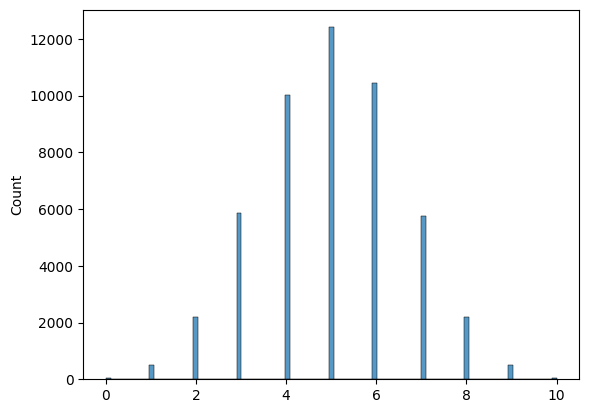

In [6]:
# Simulate 50000 experiments
sims = rng.binomial(n_tosses, p, size=50_000)
sns.histplot(sims)

In [7]:
# Calculate the probability of getting 8 heads or more
np.mean(sims >= n_heads)


np.float64(0.05526)

And that is the p-value! Here is it's official definition:

A p-value is the probability of obtaining the observed result, assuming that the null hypothesis is true.

Stop to think about how it relates to the simple simulation that we wrote above. Specifically:
- What was the "observed result"?
- What was the null hypothesis?
- Would you say the result is surprising? Why or why not?


### Simulating an experiment

Suppose we ran an experiment where we were trying to improve conversion from visitor to buyer in our eshop by recommending products to our users more aggresively. Also suppose that we are omniscient and know that this treatment has no effect - the recommendations we are making are not what our users really want. In other words, in this experiment we know that the null hypothesis is true and the treatment effect is zero.


In [8]:
n = 250 # sample size per group
conv_a = 0.30 # baseline conversion rate
te = 0.0 # treatment effect
conv_b = 0.30 + te # treatment conversion rate
alpha = 0.05 # significance level


In [9]:
conv_a_obs = rng.binomial(n, conv_a) / n
conv_b_obs = rng.binomial(n, conv_b) / n
te_obs = conv_b_obs - conv_a_obs

print("Control Rate: ", conv_a_obs)
print("Treatment Rate: ", conv_b_obs)

print(round(te_obs, 4))


Control Rate:  0.312
Treatment Rate:  0.24
-0.072


In [10]:
te_obs_list = []
for i in range(50_000):
    conv_a_obs = rng.binomial(n, conv_a) / n
    conv_b_obs = rng.binomial(n, conv_b) / n
    te_obs_list.append(conv_b_obs - conv_a_obs)

te_obs_list = np.array(te_obs_list)


Text(0.5, 1.0, 'Sampling distribution under the null')

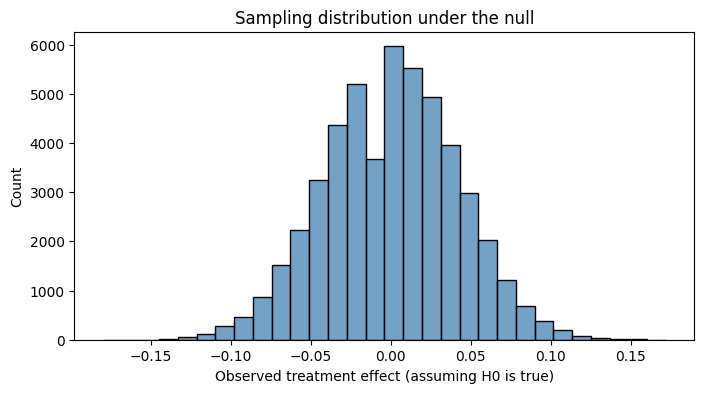

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(te_obs_list, bins=30, ax=ax, color="steelblue")

ax.set_xlabel("Observed treatment effect (assuming H0 is true)")
ax.set_title("Sampling distribution under the null")


Now we can ask - suppose we ran the experiment only once and observed an increase in conversion of 0.02 (2 percentage points). What is the probability of such a difference (positive or negative) assuming the null hypothesis is true?

One important caveat is that we are usually conducting two-sided tests, that is, we're interested in detecting an absolute difference between the groups, rather than just whather one was bigger/smaller.


In [12]:
te_obs = 0.02 # treatment effect
np.mean(np.abs(te_obs_list) >= te_obs)

np.float64(0.63854)

Given baseline conversion rate of 0.3 and sample size of 500, observing an increase or decrease of 2 percentage points or more is not at all unlikely - the p value is around 0.64.

We developed this simulation for the purpose of building intuition, but of course in practice we can use statistical packages to perform these calculations.

We only need the simulation for intuition. In reality we use a statistical test, such as the z-test.


In [13]:
def z_test_pvalue(x_a, n_a, x_b, n_b):
    """
    x_a - number of successes in group A
    n_a - sample size of group A
    x_b - number of successes in group B
    n_b - sample size of group B
    """
    p_pool = (x_a + x_b) / (n_a + n_b)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n_a + 1/n_b))
    p_a = x_a / n_a
    p_b = x_b / n_b
    z  = (p_b - p_a) / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return p


In [14]:
n = 250
conv_a_obs = 0.3
conv_b_obs = 0.32
x_a = n * conv_a_obs
x_b = n * conv_b_obs
(x_a, x_b)


(75.0, 80.0)

In [15]:
test_stat, p_value = proportions_ztest(
    [x_a, x_b], [n, n]
)
p_value

np.float64(0.628754090690459)

### Confidence Intervals
We can either present our results via p-values, or via confidence intervals. Confidence intervals are often preferable because they show the variation in the estimate of the treatment effect.

Let's look at how confidence intervals are calculated.

When calculating the p-value, we took the standard error and calculated the z-score, which shows how many standard errors away is the difference. That determined the p-value that we can then compare against alpha.

When calculating confidence intervals we essentially flip the question - for our chosen confidence level alpha, how high would the z-score need to be (how many standard errors should the observed difference be) such that we would consider the result significant? This also gives us a z-score that we can use to calculate the confidence interval.


In [16]:
conv_a = 0.3
te = 0.02
conv_b = conv_a + te
n = 250

alpha = 0.05
z = stats.norm.ppf(1 - alpha/2)
z # ~ 1.96


np.float64(1.959963984540054)

In [17]:
conv_a_obs = rng.binomial(n, conv_a) / n
conv_b_obs = rng.binomial(n, conv_b) / n

# same calculation as for the p-value, just simplified
conv_pool = (conv_a_obs + conv_b_obs) / 2
se = np.sqrt(conv_pool * (1 - conv_pool) * (1/n + 1/n))

te_obs = conv_b_obs - conv_a_obs
conf_int_lower = te_obs - z * se
conf_int_upper = te_obs + z * se

conf_int_lower.round(3), conf_int_upper.round(3)


(np.float64(-0.069), np.float64(0.093))

Here, the confidence interval has a pretty wide range, and it includes 0. Which means that we cannot reject the null hypothesis - it is plausible that the effect is actually 0.

This means that in these experiments the sample size is too small to detect the treatment effect of 2 percentage points. Even though there is an effect (we developed our simulation such that there would be an effect), we do not have enough data to reliably say that the two groups are different.

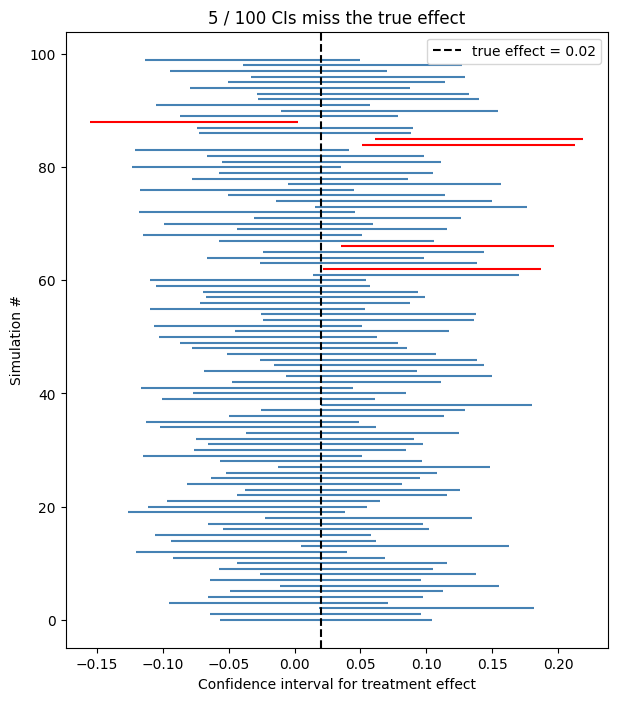

In [18]:
n_sims = 100
lower_cis = []
upper_cis = []
for i in range(n_sims):
    conv_a_obs = rng.binomial(n, conv_a) / n
    conv_b_obs = rng.binomial(n, conv_b) / n

    se = np.sqrt(conv_a_obs * (1 - conv_a_obs) / n + conv_b_obs * (1 - conv_b_obs) / n)

    te_obs = conv_b_obs - conv_a_obs
    lower_cis.append(te_obs - z * se)
    upper_cis.append(te_obs + z * se)

lower_cis = np.array(lower_cis)
upper_cis = np.array(upper_cis)
covers = (lower_cis <= te) & (upper_cis >= te)
colors = np.where(covers, "steelblue", "red")

fig, ax = plt.subplots(figsize=(7, 8))
ax.hlines(y=range(n_sims), xmin=lower_cis, xmax=upper_cis, colors=colors)
ax.axvline(x=te, color="black", linestyle="--", label=f"true effect = {te}")
ax.set_xlabel("Confidence interval for treatment effect")
ax.set_ylabel("Simulation #")
ax.set_title(f"{(~covers).sum()} / {n_sims} CIs miss the true effect")
ax.legend()

# at 95% confidence, ~5% of intervals should miss the true effect.


p-values:
1. Calculate $z$ - divide observed difference by standard error.
2. Turn the z-score into tail probability - ask what fraction of the normal curve lies beyond $abs(z)$.
3. compare that against $\alpha$

confidence interval:
1. For your $\alpha$, calculate the critical value $z$ - the z-score at which the result would be considered significant. For $\alpha = 0.05$ this is equal to 1.96.
2. Calculate the standard error and multiply $z$ by standard error to get the margin of error. Observed difference +- MOE is the confidence interval.

A $(1-\alpha) * 100\% $  confidence interval that excludes the null value (e.g., 0 for a difference) is equivalent to a p-value below $\alpha$, while an interval that includes the null corresponds to a p-value above $\alpha$.

### Type 1 and Type 2 errors

There are two ways an AB test can lead us to the wrong conclusion:

|  | $H_0$ true (no effect) | $H_1$ true (real effect) |
| --- | --- | --- |
| **Reject $H_0$** | Type I error (false positive) | Correct |
| **Don't reject $H_0$** | Correct | Type II error (false negative) |

- $\alpha$ = P(Type I error) = significance level. We pick this directly, typically 0.05.
- $\beta$ = P(Type II error). Depends on sample size, the true effect size, and $\alpha$.
- **Power** = $1 - \beta$ = probability of detecting a real effect when one exists.

Standard defaults: $\alpha = 0.05$, power = 0.8 (so $\beta = 0.2$).


### Power analysis

Earlier we saw that with $n = 250$ we couldn't reliably detect a 2pp lift - the test was underpowered. Power analysis flips the question we asked before: instead of computing a p-value from data, we ask **how many users we need to detect an effect of a given size**.

We set these four quantities:
1. **Baseline rate** (current conversion / retention).
2. **MDE (minimum detectable effect)** - the smallest effect we want to be able to detect. In AB tests MDE is usually the smallest effect that would be meaningful for the business.
3. **$\alpha$** - typically 0.05.
4. **Power** - typically 0.8.

And by applying a formula on them we get the required sample size.

In [19]:
# How many users do we need to detect a 2pp lift on a 30% baseline conversion?
baseline = 0.3
mde = 0.02    # 2 percentage points
alpha = 0.05
power = 0.8

p_avg = baseline + mde / 2
z_alpha = stats.norm.ppf(1 - alpha / 2)
z_beta = stats.norm.ppf(power)

n = ((z_alpha + z_beta) ** 2 * 2 * p_avg * (1 - p_avg)) / mde ** 2
print(f"Required sample size per group: ~{int(n):,}")


Required sample size per group: ~8,394


## Analysing a real experiment

Let's now analyse a real experiment.


### AB Test Workflow

A typical AB test follows these steps:

1. **Begin with a product problem and a hypothesis.** What change do we want to make, and why do we think it will help? Suppose we built a new recommender system for our eshop and we believe the new recommendations will get more visitors to make a purchase.
    - $H_0$ (null): the new recommender does **not** change the purchase rate.
    - $H_1$ (alternative): the new recommender **does** change the purchase rate.

2. **Define a primary metric (and guardrails).** The primary metric is what we use to decide if the test succeeded; guardrails are metrics that should not get worse. Our primary metric is the purchase rate (visitor → buyer), and guardrails could be average order value and 30-day retention - we don't want to push more purchases at the cost of smaller baskets or churn.

3. **Calculate the required sample size (power analysis).** Given the baseline rate, the smallest effect we care about (MDE), $\alpha$, and the desired power, we work out how many users we need per group. With baseline purchase rate of 5%, MDE of 0.5 percentage points, $\alpha = 0.05$ and power = 0.8, we would need roughly 30,000 visitors per group.

4. **Run the experiment.** Randomly assign users to groups, run for a fixed duration until you accumulate the required sample size. For example - half of our visitors see the old recommendations and half see the new ones, for two weeks.

5. **Analyse the results.** Compute the confidence interval for the primary metric and the guardrails. We compare purchase rates between the two groups and verify that average order value and retention did not drop.

6. **Make a decision.** Reject $H_0$ if $p < \alpha$ (equivalently, if 0 is outside the CI).


### Task 1

Read the dataset description [here](https://www.kaggle.com/code/mursideyarkin/mobile-games-ab-testing-with-cookie-cats) and look at the dataset. Identify the following components:
- Treatment
- Treatment unit (subject)
- The number of groups in the test
- Which group is the control group


In [20]:
url = 'https://pub-c88b3a7f2ed141418355b2bfb03c96e6.r2.dev/cookie_cats.csv'
request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(request) as response:
    df = pd.read_csv(response)
df.shape

(90189, 5)

### Task 2

Analyse the experiment - calculate the p-value and the confidence interval for the difference in 1-day retention rates between the groups. Write down the interpretation of both the p-value and confidence interval.

Assume alpha level of 0.05.

Would you recommend to scale the experiment?

Note: for confidence interval use `confint_proportions_2indep(count1, nobs1, count2, nobs2)`


### Caveats

- **Continuous metrics**. In this lecture we only used conversion (binomial) metrics. For continuous outcomes (revenue, time spent, number of items bought) we use a t-test for the difference of means instead. The intuition for p-values and CIs is the same.
- **P-value misinterpretations**. Two common wrong readings:
    - "p < 0.05 means there is a 5% chance the null hypothesis is true."
    - "p < 0.05 means the treatment works."
- **Statistical vs practical significance**. With enough data, even tiny differences become statistically significant, therefore you also have to think if the uplift matters for business.
- **Multiple testing**. The more metrics we look at, the higher the chance at least one looks significant by chance. With 20 independent tests at $\alpha = 0.05$ we'd expect ~1 false positive; in practice metrics are correlated so the rate is lower, but it still grows with the number of tests.
- **When we cannot run an experiment**. Sometimes randomization is impossible or unethical:
    - The impact of minimum wage on unemployment - the researcher cannot control minimum wage.
    - Setting the optimal price - illegal to show different prices for the same item to different customers in the same region.
    - A change in terms and services of a platform (e.g. shorten refund period from 30 days to 7 days).

    In these cases we collect observational data and apply methods from econometrics / causal inference.

The statistics of AB testing get more complex in practice, but the intuition you built in this lecture carries over - and very often these exact formulas can be applied as-is.


## Recap

1. A randomized controlled experiment is an experiment that has these components:
    1. There is a control group that does not receive the treatment.
    2. Units are assigned into control and treatment groups randomly.
    3. Aside from the treatment, everything is the same between groups.
2. AB tests are what technology companies call randomized controlled experiments.
3. We need AB tests because our intuition is wrong, and we need to back our decisions with data.
4. A key component of running successful AB tests is a valid target metric.
5. We can summarize the results of an experiment via a p-value or a confidence interval.

| number | question that it answers | interpretation |
| ------ | ---- | --- |
|   p-value | if the true effect is zero, how surprising is the observed result? | if p value is below $\alpha$, we reject the null hypothesis |
| confidence interval | which effect sizes are consistent with the data? | the narrower the interval, the more precise is our estimate. 0 being outside of the interval is equivalent to a significant effect  |